# Example for bssunfold package with Lanczos, GKS, EPIC, CS, and other advanced methods

This notebook demonstrates various advanced unfolding methods:
- `unfold_lanczos`: Lanczos-type (Golub-Kahan) hybrid unfolding with GCV regularization
- `unfold_gks`: Generalized Krylov Subspace method
- `unfold_tikhonov_tv`: Tikhonov and Total Variation regularization (modes: 'TT', 'TV', 'T')
- `unfold_epic`: EPIC method
- `unfold_cs`: Compressive Sensing method
- `unfold_scip`: SCIP optimization solver
- `unfold_docplex`: DOcplex optimization solver

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from bssunfold import Detector, RF_LANL
from bssunfold.utils.plotting import plot_comparison

## Setup detector and reference spectrum

In [4]:
det = Detector(RF_LANL)
reference_spectrum = pd.read_csv('../tests/MonteCarlo_Calculated_spectra_from_IAEA_Comp_for_comparison.csv')
readings = det.get_effective_readings_for_spectra(reference_spectrum[['E_MeV','ISO_ref_Cf252']])

## Apply various unfolding methods

In [5]:
# Lanczos method
result_lanczos = det.unfold_lanczos(readings)

# GKS method
result_gks = det.unfold_gks(readings)

# Tikhonov-TV method (default 'TT' mode)
result_tikhonov_tv = det.unfold_tikhonov_tv(readings)

# EPIC method
result_epic = det.unfold_epic(readings)

# Compressive Sensing method
result_cs = det.unfold_cs(readings)

# SCIP method
result_scip = det.unfold_scip(readings)

# DOcplex method
result_docplex = det.unfold_docplex(readings)

## Plot comparison of results

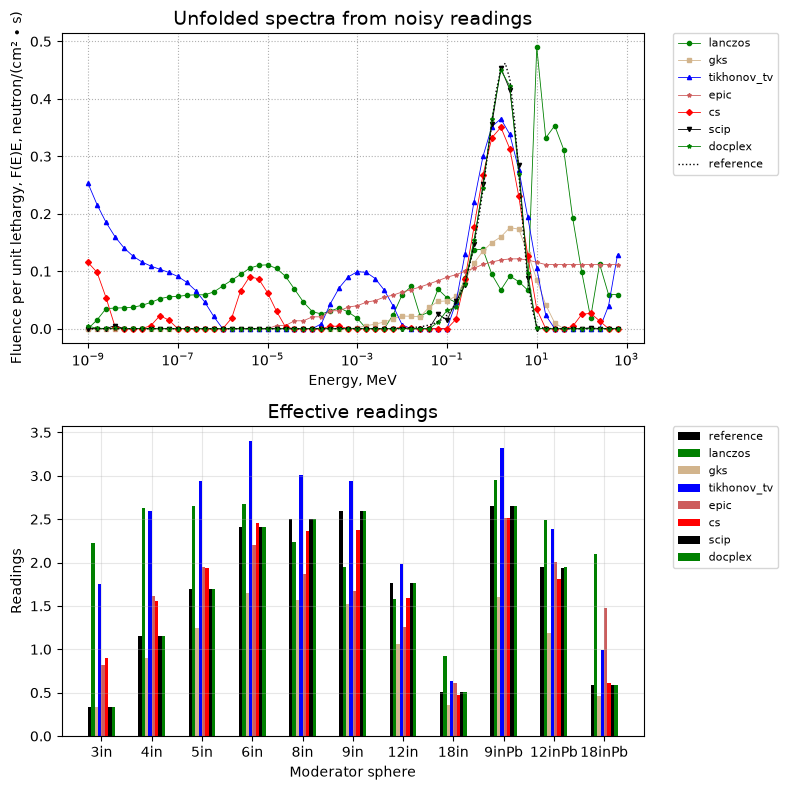

In [6]:
results = {
    "lanczos": result_lanczos,
    "gks": result_gks,
    "tikhonov_tv": result_tikhonov_tv,
    "epic": result_epic,
    "cs": result_cs,
    "scip": result_scip,
    "docplex": result_docplex,
}

fig, ax = plot_comparison(
    results=results,
    readings=readings,
    reference_spectrum=reference_spectrum[["E_MeV", "ISO_ref_Cf252"]],
)

## Spectrum plots for each method

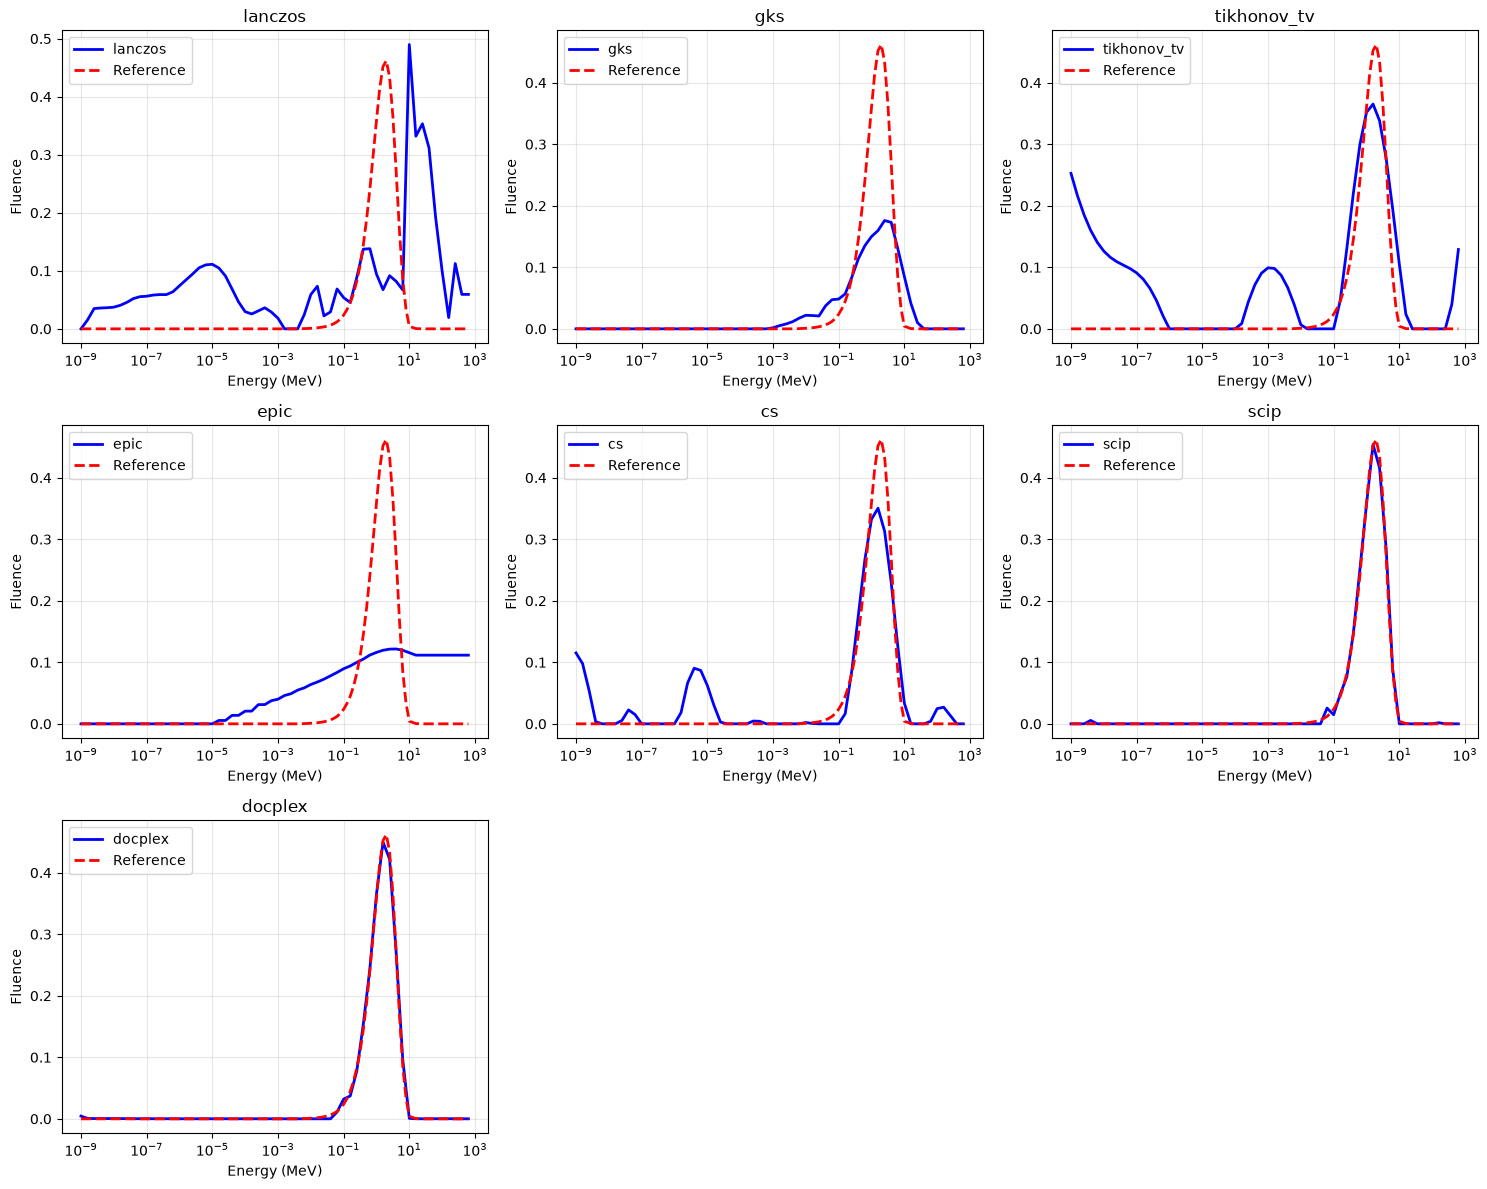

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

method_names = list(results.keys())

for idx, (name, result) in enumerate(results.items()):
    ax = axes[idx]
    ax.plot(det.E_MeV, result['spectrum'], 'b-', label=f'{name}', linewidth=2)
    ax.plot(reference_spectrum['E_MeV'], reference_spectrum['ISO_ref_Cf252'], 'r--', label='Reference', linewidth=2)
    ax.set_xlabel('Energy (MeV)')
    ax.set_ylabel('Fluence')
    ax.set_title(f'{name}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xscale('log')
    ax.set_yscale('linear')

# Hide unused subplots
for idx in range(len(results), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

## Summary

This notebook demonstrated several advanced unfolding methods available in bssunfold:

1. **Lanczos**: Krylov subspace method with automatic GCV regularization selection
2. **GKS**: Generalized Krylov Subspace approach
3. **Tikhonov-TV**: Combined Tikhonov and Total Variation regularization
4. **EPIC**: Advanced iterative method
5. **CS**: Compressive Sensing with sparse representation
6. **SCIP**: SCIP optimization solver
7. **DOcplex**: IBM DOcplex optimizer

Each method has its strengths depending on the specific characteristics of the measurement problem.